In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r"Churn_Modelling_with_nulls.csv")

In [3]:
df1 = df.copy()

In [4]:
df1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602.0,Hargrave,619.0,France,Female,NaN,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,2,15647311.0,Hill,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,3,15619304.0,Onio,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,4,15701354.0,Boni,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,5,15737888.0,Mitchell,850.0,Spain,Female,43.0,NaN,125510.82,1.0,1.0,1.0,79084.10,0.0


In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       9505 non-null   float64
 2   Surname          9467 non-null   str    
 3   CreditScore      9484 non-null   float64
 4   Geography        9498 non-null   str    
 5   Gender           9519 non-null   str    
 6   Age              9481 non-null   float64
 7   Tenure           9486 non-null   float64
 8   Balance          9503 non-null   float64
 9   NumOfProducts    9514 non-null   float64
 10  HasCrCard        9503 non-null   float64
 11  IsActiveMember   9503 non-null   float64
 12  EstimatedSalary  9519 non-null   float64
 13  Exited           9522 non-null   float64
dtypes: float64(10), int64(1), str(3)
memory usage: 1.1 MB


In [6]:
df1.isnull().sum()

RowNumber            0
CustomerId         495
Surname            533
CreditScore        516
Geography          502
Gender             481
Age                519
Tenure             514
Balance            497
NumOfProducts      486
HasCrCard          497
IsActiveMember     497
EstimatedSalary    481
Exited             478
dtype: int64

In [7]:
df1["CreditScore"] = df1["CreditScore"].fillna(df1["CreditScore"].mean())

df1["Age"] = df1["Age"].fillna(df1["Age"].mean())

df1["Balance"] = df1["Balance"].fillna(df1["Balance"].mean())

df1["EstimatedSalary"] = df1["EstimatedSalary"].fillna(df1["EstimatedSalary"].mean())

In [8]:
df1["Tenure"] = df1["Tenure"].fillna(df1["Tenure"].mode()[0])

df1["NumOfProducts"] = df1["NumOfProducts"].fillna(df1["NumOfProducts"].mode()[0])

df1["HasCrCard"] = df1["HasCrCard"].fillna(df1["HasCrCard"].mode()[0])

df1["IsActiveMember"] = df1["IsActiveMember"].fillna(df1["IsActiveMember"].mode()[0])

df1["Gender"] = df1["Gender"].fillna(df1["Gender"].mode()[0])

df1["Geography"] = df1["Geography"].fillna(df1["Geography"].mode()[0])

In [9]:
df1.isnull().sum()

RowNumber            0
CustomerId         495
Surname            533
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited             478
dtype: int64

In [10]:
df1 = df1.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [11]:
df1.isnull().sum()

CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited             478
dtype: int64

In [12]:
le = LabelEncoder()

In [13]:
df1["Gender"] = le.fit_transform(df1["Gender"])
df1["Geography"] = le.fit_transform(df1["Geography"])

In [14]:
df1["Exited"].isnull().sum()

np.int64(478)

In [15]:
df1 = df1.dropna(subset=["Exited"])

In [16]:
df1["Exited"].isnull().sum()

np.int64(0)

In [17]:
X = df1.drop("Exited", axis=1)
y = df1["Exited"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
df1.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [20]:
y.isnull().sum()

np.int64(0)

In [21]:
df1["Exited"].isnull().sum()

np.int64(0)

In [22]:
df1["Exited"].value_counts(dropna=False)

Exited
0.0    7595
1.0    1927
Name: count, dtype: int64

In [23]:
X_train.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
y_pred = model.predict(X_test)

C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy = accuracy_score(y_test, y_pred)

In [31]:
print("Accuracy =", accuracy)

Accuracy = 0.6593175853018373


In [32]:
from sklearn.metrics import confusion_matrix

In [33]:
cm = confusion_matrix(y_test, y_pred)

In [34]:
print(cm)

[[1061  451]
 [ 198  195]]


In [35]:
from sklearn.metrics import classification_report

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.84      0.70      0.77      1512
         1.0       0.30      0.50      0.38       393

    accuracy                           0.66      1905
   macro avg       0.57      0.60      0.57      1905
weighted avg       0.73      0.66      0.69      1905



In [37]:
new_customer = [[650,1,1,40,5,60000,2,1,1,70000]]

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

Customer Will Stay


C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [38]:
model.predict_proba(new_customer)

C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.90268658, 0.09731342]])

<Axes: xlabel='Exited'>

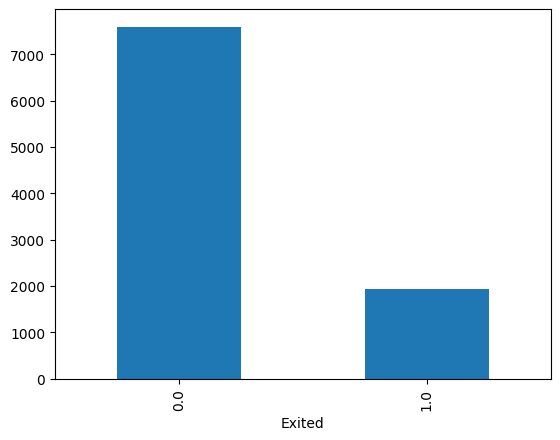

In [39]:
df1["Exited"].value_counts().plot(kind="bar")

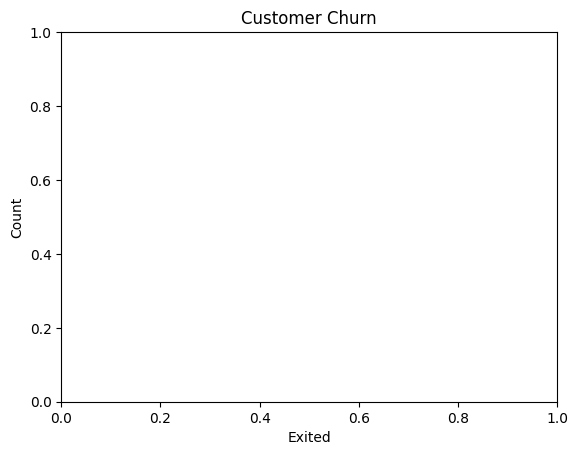

In [40]:
plt.title("Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

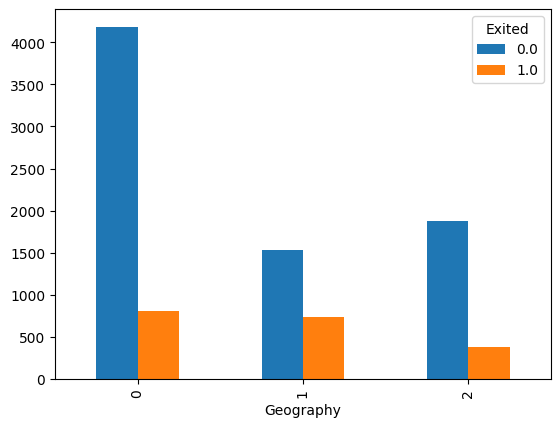

In [41]:
pd.crosstab(df1["Geography"], df1["Exited"]).plot(kind="bar")

plt.show()

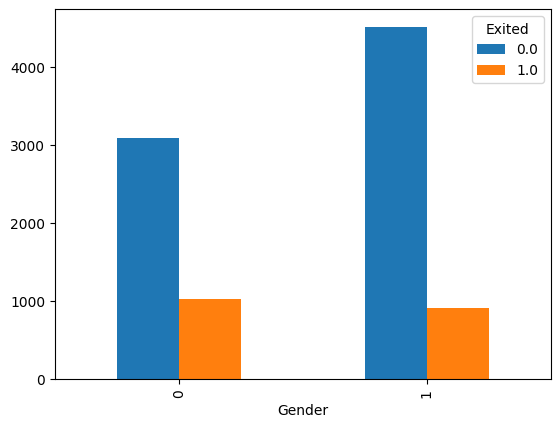

In [42]:
pd.crosstab(df1["Gender"], df1["Exited"]).plot(kind="bar")

plt.show()

In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [44]:
ann = Sequential()

In [45]:
ann.add(Dense(units=16, activation="relu", input_dim=X_train.shape[1]))

ann.add(Dense(units=8, activation="relu"))

ann.add(Dense(units=1, activation="sigmoid"))

C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
history = ann.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7875 - loss: 0.5383 - val_accuracy: 0.8077 - val_loss: 0.4771
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8062 - loss: 0.4574 - val_accuracy: 0.8235 - val_loss: 0.4299
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8188 - loss: 0.4248 - val_accuracy: 0.8314 - val_loss: 0.4083
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8287 - loss: 0.4056 - val_accuracy: 0.8419 - val_loss: 0.3953
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8390 - loss: 0.3914 - val_accuracy: 0.8451 - val_loss: 0.3812
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8436 - loss: 0.3799 - val_accuracy: 0.8497 - val_loss: 0.3737
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8457 - loss: 0.3710 - val_accuracy: 0.8510 - val_loss: 0.3680
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8482 - loss: 0.3650 - val_accuracy: 0.

In [48]:
loss, accuracy = ann.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8430 - loss: 0.3652
Loss : 0.36524850130081177
Accuracy : 0.843044638633728


In [49]:
y_pred = ann.predict(X_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [50]:
y_pred = (y_pred > 0.5)

print(y_pred)

[[ True]
 [False]
 [False]
 ...
 [False]
 [False]
 [False]]


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1457   55]
 [ 244  149]]


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91      1512
         1.0       0.73      0.38      0.50       393

    accuracy                           0.84      1905
   macro avg       0.79      0.67      0.70      1905
weighted avg       0.83      0.84      0.82      1905



In [53]:
new_customer = [[650,1,1,40,5,60000,2,1,1,70000]]

new_customer = scaler.transform(new_customer)

prediction = ann.predict(new_customer)

if prediction[0][0] > 0.5:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Customer Will Stay


C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


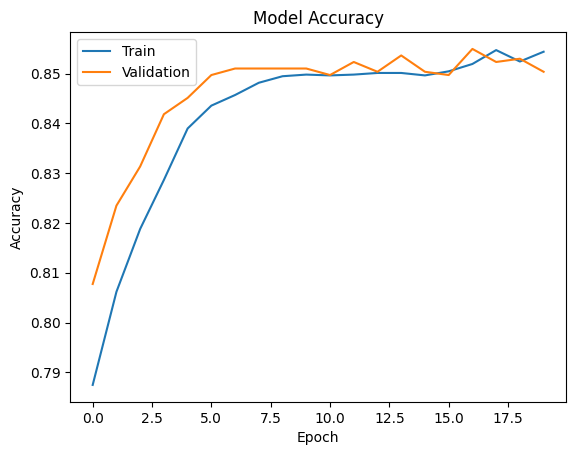

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

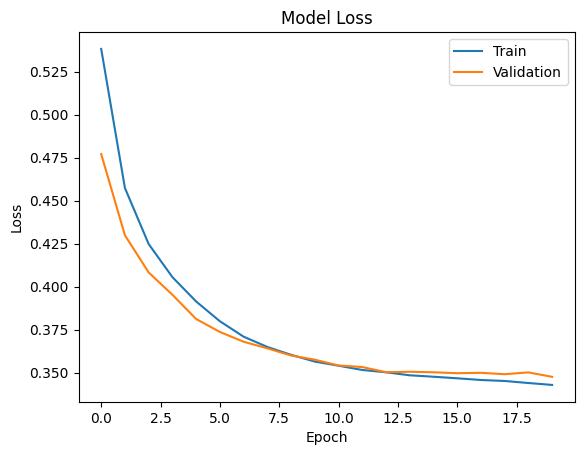

In [55]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()